# DataDriven_Soccer_Scouting

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
#from tensorflow.keras import layers, models
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import time


import warnings
warnings.filterwarnings("ignore")



start_time = time.time()

## Introduction and EDA

In [2]:
df = pd.read_csv("merged_data.csv")
# Convert 'season' to a more readable format (e.g., '2020 - 2021')
df['season'] = df['season'].astype(str).str.zfill(4)
df['season'] = "20" + df['season'].str[:2] + " - 20" + df['season'].str[2:]

# Keep "Position" column instead of "pos"
df.drop(columns=['pos'], inplace=True)
df = df.rename(columns={'Position': 'pos'})

display(df.head())
print('\nRows: {}, Columns: {}'.format(df.shape[0], df.shape[1]))

,league,season,team,player,nation,age,born,Playing Time_MP,Playing Time_Starts,Playing Time_Min,...,Touches_Att Pen,Touches_Def 3rd,Touches_Def Pen,Touches_Live,Touches_Mid 3rd,Touches_Touches,Height,Weight,Preferred foot,pos
0,ENG-Premier League,2024 - 2025,Arsenal,Ben White,ENG,26,1997,17,13,1198,...,28,214,55,813,367,813,NaN,NaN,NaN,NaN
1,ENG-Premier League,2024 - 2025,Arsenal,Bukayo Saka,ENG,22,2001,25,20,1729,...,162,57,6,978,216,979,178.0,65.0,Left,RW
2,ENG-Premier League,2024 - 2025,Arsenal,David Raya,ESP,28,1995,38,38,3420,...,0,1388,880,1480,92,1480,183.0,75.0,Right,GK
3,ENG-Premier League,2024 - 2025,Arsenal,Declan Rice,ENG,25,1999,35,33,2825,...,81,325,82,1948,909,1948,185.0,80.0,Right,CDM
4,ENG-Premier League,2024 - 2025,Arsenal,Gabriel Magalhães,BRA,26,1997,28,28,2363,...,40,672,189,1873,985,1873,NaN,NaN,NaN,NaN



Rows: 4807, Columns: 117


In [3]:
# Removing rows with null values and Goalkeepers (GK)
not_null_df = df.dropna()
not_null_df = not_null_df[not_null_df['pos'] != 'GK']
print('data without null and GKs\n- rows: {} \n- columns: {}'.format(not_null_df.shape[0], not_null_df.shape[1]))
df_backup = df.copy()
df = not_null_df.copy()

data without null and GKs
- rows: 3392 
- columns: 117


In [4]:
# Select all not numeric columns
not_numeric_cols = df.select_dtypes(exclude=[np.number]).columns
display(df[not_numeric_cols].head())

,league,season,team,player,nation,Preferred foot,pos
1,ENG-Premier League,2024 - 2025,Arsenal,Bukayo Saka,ENG,Left,RW
3,ENG-Premier League,2024 - 2025,Arsenal,Declan Rice,ENG,Right,CDM
5,ENG-Premier League,2024 - 2025,Arsenal,Gabriel Martinelli,BRA,Right,LW
6,ENG-Premier League,2024 - 2025,Arsenal,Jakub Kiwior,POL,Left,CB
7,ENG-Premier League,2024 - 2025,Arsenal,Jurriën Timber,NED,Right,RB


In [5]:
# Rename 'Preferred foot' to 'preferred_foot' for consistency
df.rename(columns={'Preferred foot': 'preferred_foot'}, inplace=True)

# Convert preferred_foot to binary (1 for 'Right', 0 for 'Left')
df['preferred_foot_binary'] = df['preferred_foot'].map({'Right': 1, 'Left': 0})

# Identify info columns and create a separate DataFrame for them
info_columns = ['league', 'season', 'team', 'player', 'nation', 'pos', 'born', 'age', 'preferred_foot']
df_info = df[[col for col in df.columns if col.lower() in info_columns]].copy()
numeric_features = df.select_dtypes(include=[np.number]).columns
features = [col for col in numeric_features if col.lower() not in info_columns]

X = df[features].copy()

print(f"Matrix 'X' shape: {X.shape[0]} players x {X.shape[1]} statistics")

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


Matrix 'X' shape: 3392 players x 109 statistics


## Similarity Search

### PCA - BOSCA

In [6]:
# ----------------------------------------------
# NON RIMUOVERE QUESTA CELLA
# ----------------------------------------------
df_info_reset = df_info.reset_index(drop=True)

In [ ]:
print("--- PCA Analysis ---")
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Fit PCA with all components to analyze explained variance
pca_full = PCA()
pca_full.fit(X_scaled)

# Get explained variance ratio
explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print(f"Total features: {X_scaled.shape[1]}")
print(f"Explained variance by first 10 components: {cumulative_variance[:10]}")
print(f"Variance explained by first 20 components: {cumulative_variance[19] if len(cumulative_variance) > 19 else cumulative_variance[-1]:.4f}")

# Find optimal number of components (95% variance)
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Components needed for 95% variance: {n_components_95}")

# Find optimal number of components (90% variance)
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1
print(f"Components needed for 90% variance: {n_components_90}")

# Visualize explained variance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Individual explained variance
axes[0].bar(range(1, min(51, len(explained_variance) + 1)), explained_variance[:50], alpha=0.7, color='steelblue')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('PCA: Individual Explained Variance Ratio')
axes[0].grid(alpha=0.3)

# Plot 2: Cumulative explained variance
axes[1].plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'o-', color='steelblue', linewidth=2)
axes[1].axhline(y=0.95, color='r', linestyle='--', label='95% variance')
axes[1].axhline(y=0.90, color='orange', linestyle='--', label='90% variance')
axes[1].axvline(x=n_components_95, color='r', linestyle=':', alpha=0.5)
axes[1].axvline(x=n_components_90, color='orange', linestyle=':', alpha=0.5)
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('PCA: Cumulative Explained Variance')
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Deep Autoencoder - MURA

In [ ]:
# Apply PCA with optimal components (90% variance)
n_components = n_components_90
print(f"\nFitting PCA with {n_components} components...")

pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)

print(f"PCA transformed data shape: {X_pca.shape}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.4f}")

# Create a DataFrame with PCA components
pca_columns = [f'PC_{i+1}' for i in range(n_components)]
df_pca = pd.DataFrame(X_pca, columns=pca_columns)
df_pca['player'] = df_info['player'].values
df_pca['position'] = df_info['position'].values
df_pca['league'] = df_info['league'].values
df_pca['season'] = df_info['season'].values

print("\nPCA DataFrame created:")
print(df_pca.head())

In [ ]:
# Visualize 2D and 3D PCA projections
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 2D scatter: PC1 vs PC2
scatter1 = axes[0, 0].scatter(X_pca[:, 0], X_pca[:, 1], c=range(X_pca.shape[0]), cmap='viridis', alpha=0.6, s=30)
axes[0, 0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
axes[0, 0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
axes[0, 0].set_title('PCA: PC1 vs PC2')
axes[0, 0].grid(alpha=0.3)

# 2D scatter: PC1 vs PC3
scatter2 = axes[0, 1].scatter(X_pca[:, 0], X_pca[:, 2], c=range(X_pca.shape[0]), cmap='viridis', alpha=0.6, s=30)
axes[0, 1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
axes[0, 1].set_ylabel(f'PC3 ({pca.explained_variance_ratio_[2]:.2%} variance)')
axes[0, 1].set_title('PCA: PC1 vs PC3')
axes[0, 1].grid(alpha=0.3)

# 2D scatter: PC2 vs PC3
scatter3 = axes[1, 0].scatter(X_pca[:, 1], X_pca[:, 2], c=range(X_pca.shape[0]), cmap='viridis', alpha=0.6, s=30)
axes[1, 0].set_xlabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
axes[1, 0].set_ylabel(f'PC3 ({pca.explained_variance_ratio_[2]:.2%} variance)')
axes[1, 0].set_title('PCA: PC2 vs PC3')
axes[1, 0].grid(alpha=0.3)

# Explained variance ratio for first 10 components
axes[1, 1].bar(range(1, min(11, len(pca.explained_variance_ratio_) + 1)), 
               pca.explained_variance_ratio_[:10], color='steelblue', alpha=0.7)
axes[1, 1].set_xlabel('Principal Component')
axes[1, 1].set_ylabel('Explained Variance Ratio')
axes[1, 1].set_title(f'PCA: First 10 Components (Total: {n_components})')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nPCA Components Summary:")
for i in range(min(5, len(pca.explained_variance_ratio_))):
    print(f"PC{i+1}: {pca.explained_variance_ratio_[i]:.4f} ({np.sum(pca.explained_variance_ratio_[:i+1]):.4f} cumulative)")

#### Mix ReLU

In [76]:
'''print("--- Building Deep Autoencoder (TensorFlow/Keras) ---")

input_dim = X_scaled.shape[1]

# ==========================================
# 1. MODEL ARCHITECTURE
# ==========================================
# Input
input_layer = layers.Input(shape=(input_dim,))

# ENCODER (ReLU + tanh mix)
encoded = layers.Dense(64, activation='relu')(input_layer)
encoded = layers.Dense(32, activation='tanh')(encoded)

# BOTTLENECK (10-dimensional latent space)
bottleneck_layer = layers.Dense(10, activation='relu', name='dna_bottleneck')(encoded)

# DECODER (Reconstruction)
decoded = layers.Dense(32, activation='tanh')(bottleneck_layer)
decoded = layers.Dense(64, activation='relu')(decoded)

# Final output (returns to original number of features, linear)
output_layer = layers.Dense(input_dim, activation='linear')(decoded)

# ==========================================
# 2. COMPILE AND TRAIN
# ==========================================
autoencoder = models.Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='huber')

print("\nTraining in progress...")
autoencoder.fit(X_scaled, X_scaled, epochs=100, batch_size=32, verbose=1)
print("Training completed!")

plot_loss = autoencoder.history.history['loss']
plt.plot(plot_loss)
plt.title("Training loss")
plt.xlabel("Epoch")
plt.ylabel("Huber Loss")
plt.show()

# ==========================================
# 3. LATENT SPACE EXTRACTION
# ==========================================
print("\nExtracting 10D DNA representation...")

encoder = models.Model(inputs=input_layer, outputs=bottleneck_layer)
bottleneck = encoder.predict(X_scaled)

ae_columns = [f'AE_{i+1}' for i in range(10)]
df_ae_mix_relu = pd.DataFrame(bottleneck, columns=ae_columns)
df_latent_ae_mix_relu = pd.concat([df_info_reset, df_ae_mix_relu], axis=1)'''

'print("--- Building Deep Autoencoder (TensorFlow/Keras) ---")\n\ninput_dim = X_scaled.shape[1]\n\n# ==========================================\n# 1. MODEL ARCHITECTURE\n# ==========================================\n# Input\ninput_layer = layers.Input(shape=(input_dim,))\n\n# ENCODER (ReLU + tanh mix)\nencoded = layers.Dense(64, activation=\'relu\')(input_layer)\nencoded = layers.Dense(32, activation=\'tanh\')(encoded)\n\n# BOTTLENECK (10-dimensional latent space)\nbottleneck_layer = layers.Dense(10, activation=\'relu\', name=\'dna_bottleneck\')(encoded)\n\n# DECODER (Reconstruction)\ndecoded = layers.Dense(32, activation=\'tanh\')(bottleneck_layer)\ndecoded = layers.Dense(64, activation=\'relu\')(decoded)\n\n# Final output (returns to original number of features, linear)\noutput_layer = layers.Dense(input_dim, activation=\'linear\')(decoded)\n\n# ==========================================\n# 2. COMPILE AND TRAIN\n# ==========================================\nautoencoder = models.Model

#### Mix Tanh

In [77]:
'''print("--- Building Deep Autoencoder (TensorFlow/Keras) ---")

input_dim = X_scaled.shape[1]

# ==========================================
# 1. MODEL ARCHITECTURE
# ==========================================
# Input
input_layer = layers.Input(shape=(input_dim,))

# ENCODER (ReLU + tanh mix)
encoded = layers.Dense(64, activation='relu')(input_layer)
encoded = layers.Dense(32, activation='tanh')(encoded)

# BOTTLENECK (10-dimensional latent space)
bottleneck_layer = layers.Dense(10, activation='tanh', name='dna_bottleneck')(encoded)

# DECODER (Reconstruction)
decoded = layers.Dense(32, activation='tanh')(bottleneck_layer)
decoded = layers.Dense(64, activation='relu')(decoded)

# Final output (returns to original number of features, linear)
output_layer = layers.Dense(input_dim, activation='linear')(decoded)

# ==========================================
# 2. COMPILE AND TRAIN
# ==========================================
autoencoder = models.Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='huber')

print("\nTraining in progress...")
autoencoder.fit(X_scaled, X_scaled, epochs=100, batch_size=32, verbose=1)
print("Training completed!")

plot_loss = autoencoder.history.history['loss']
plt.plot(plot_loss)
plt.title("Training loss")
plt.xlabel("Epoch")
plt.ylabel("Huber Loss")
plt.show()

# ==========================================
# 3. LATENT SPACE EXTRACTION
# ==========================================
print("\nExtracting 10D DNA representation...")

encoder = models.Model(inputs=input_layer, outputs=bottleneck_layer)
bottleneck = encoder.predict(X_scaled)

ae_columns = [f'AE_{i+1}' for i in range(10)]
df_ae_mix_tanh = pd.DataFrame(bottleneck, columns=ae_columns)
df_latent_ae_mix_tanh = pd.concat([df_info_reset, df_ae_mix_tanh], axis=1)'''

'print("--- Building Deep Autoencoder (TensorFlow/Keras) ---")\n\ninput_dim = X_scaled.shape[1]\n\n# ==========================================\n# 1. MODEL ARCHITECTURE\n# ==========================================\n# Input\ninput_layer = layers.Input(shape=(input_dim,))\n\n# ENCODER (ReLU + tanh mix)\nencoded = layers.Dense(64, activation=\'relu\')(input_layer)\nencoded = layers.Dense(32, activation=\'tanh\')(encoded)\n\n# BOTTLENECK (10-dimensional latent space)\nbottleneck_layer = layers.Dense(10, activation=\'tanh\', name=\'dna_bottleneck\')(encoded)\n\n# DECODER (Reconstruction)\ndecoded = layers.Dense(32, activation=\'tanh\')(bottleneck_layer)\ndecoded = layers.Dense(64, activation=\'relu\')(decoded)\n\n# Final output (returns to original number of features, linear)\noutput_layer = layers.Dense(input_dim, activation=\'linear\')(decoded)\n\n# ==========================================\n# 2. COMPILE AND TRAIN\n# ==========================================\nautoencoder = models.Model

#### Relu

In [78]:
'''print("--- Building Deep Autoencoder (TensorFlow/Keras) ---")

input_dim = X_scaled.shape[1] 

# ==========================================
# 1. MODEL ARCHITECTURE
# ==========================================
# Input
input_layer = layers.Input(shape=(input_dim,))

# ENCODER (ReLU compression)
encoded = layers.Dense(64, activation='relu')(input_layer)
encoded = layers.Dense(32, activation='relu')(encoded)

# BOTTLENECK (10-dimensional latent space)
bottleneck_layer = layers.Dense(10, activation='relu', name='dna_bottleneck')(encoded)

# DECODER (Reconstruction)
decoded = layers.Dense(32, activation='relu')(bottleneck_layer)
decoded = layers.Dense(64, activation='relu')(decoded)

# Final output (returns to original number of columns, linear)
output_layer = layers.Dense(input_dim, activation='linear')(decoded)

# ==========================================
# 2. COMPILE AND TRAIN
# ==========================================
autoencoder = models.Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='huber')

print("\nTraining in progress...")
autoencoder.fit(X_scaled, X_scaled, epochs=100, batch_size=32, verbose=1)
print("Training completed!")

plot_loss = autoencoder.history.history['loss']
plt.plot(plot_loss)
plt.title('Training loss')
plt.xlabel('Epoch')
plt.ylabel('Huber Loss')
plt.show()

# ==========================================
# 3. LATENT SPACE EXTRACTION
# ==========================================
print("\nExtracting 10D DNA representation...")

encoder = models.Model(inputs=input_layer, outputs=bottleneck_layer)
bottleneck = encoder.predict(X_scaled)

ae_columns = [f'AE_{i+1}' for i in range(10)]
df_ae_relu = pd.DataFrame(bottleneck, columns=ae_columns)
df_latent_ae_relu = pd.concat([df_info_reset, df_ae_relu], axis=1)'''

'print("--- Building Deep Autoencoder (TensorFlow/Keras) ---")\n\ninput_dim = X_scaled.shape[1] \n\n# ==========================================\n# 1. MODEL ARCHITECTURE\n# ==========================================\n# Input\ninput_layer = layers.Input(shape=(input_dim,))\n\n# ENCODER (ReLU compression)\nencoded = layers.Dense(64, activation=\'relu\')(input_layer)\nencoded = layers.Dense(32, activation=\'relu\')(encoded)\n\n# BOTTLENECK (10-dimensional latent space)\nbottleneck_layer = layers.Dense(10, activation=\'relu\', name=\'dna_bottleneck\')(encoded)\n\n# DECODER (Reconstruction)\ndecoded = layers.Dense(32, activation=\'relu\')(bottleneck_layer)\ndecoded = layers.Dense(64, activation=\'relu\')(decoded)\n\n# Final output (returns to original number of columns, linear)\noutput_layer = layers.Dense(input_dim, activation=\'linear\')(decoded)\n\n# ==========================================\n# 2. COMPILE AND TRAIN\n# ==========================================\nautoencoder = models.Mode

#### Tanh - to train

In [79]:
'''print("--- Building Deep Autoencoder (TensorFlow/Keras) ---")

input_dim = X_scaled.shape[1] 

# ==========================================
# 1. MODEL ARCHITECTURE
# ==========================================
# Input
input_layer = layers.Input(shape=(input_dim,))

# ENCODER (tanh compression)
encoded = layers.Dense(64, activation='tanh')(input_layer)
encoded = layers.Dense(32, activation='tanh')(encoded)

# BOTTLENECK (10-dimensional latent space)
bottleneck_layer = layers.Dense(10, activation='tanh', name='dna_bottleneck')(encoded)

# DECODER (Reconstruction)
decoded = layers.Dense(32, activation='tanh')(bottleneck_layer)
decoded = layers.Dense(64, activation='tanh')(decoded)

# Final output (returns to original number of columns, linear)
output_layer = layers.Dense(input_dim, activation='linear')(decoded)

# ==========================================
# 2. COMPILE AND TRAIN
# ==========================================
autoencoder = models.Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='huber')

print("\nTraining in progress...")
autoencoder.fit(X_scaled, X_scaled, epochs=200, batch_size=32, verbose=1)
print("Training completed!")

plot_loss = autoencoder.history.history['loss']
plt.plot(plot_loss)
plt.title('Training loss')
plt.xlabel('Epoch')
plt.ylabel('Huber Loss')
plt.show()

# ==========================================
# 3. LATENT SPACE EXTRACTION
# ==========================================
print("\nExtracting 10D DNA representation...")

encoder = models.Model(inputs=input_layer, outputs=bottleneck_layer)
bottleneck = encoder.predict(X_scaled)

# Save reusable encoder for web app inference
#encoder.save("saved_models/encoder_tanh.keras")

ae_columns = [f'AE_{i+1}' for i in range(10)]
df_ae_tanh = pd.DataFrame(bottleneck, columns=ae_columns)
df_latent_ae_tanh = pd.concat([df_info_reset, df_ae_tanh], axis=1)'''

'print("--- Building Deep Autoencoder (TensorFlow/Keras) ---")\n\ninput_dim = X_scaled.shape[1] \n\n# ==========================================\n# 1. MODEL ARCHITECTURE\n# ==========================================\n# Input\ninput_layer = layers.Input(shape=(input_dim,))\n\n# ENCODER (tanh compression)\nencoded = layers.Dense(64, activation=\'tanh\')(input_layer)\nencoded = layers.Dense(32, activation=\'tanh\')(encoded)\n\n# BOTTLENECK (10-dimensional latent space)\nbottleneck_layer = layers.Dense(10, activation=\'tanh\', name=\'dna_bottleneck\')(encoded)\n\n# DECODER (Reconstruction)\ndecoded = layers.Dense(32, activation=\'tanh\')(bottleneck_layer)\ndecoded = layers.Dense(64, activation=\'tanh\')(decoded)\n\n# Final output (returns to original number of columns, linear)\noutput_layer = layers.Dense(input_dim, activation=\'linear\')(decoded)\n\n# ==========================================\n# 2. COMPILE AND TRAIN\n# ==========================================\nautoencoder = models.Mode

#### ReLU with dropout

In [80]:
'''print("--- Building Deep Autoencoder (TensorFlow/Keras) ---")

input_dim = X_scaled.shape[1] 

# ==========================================
# 1. MODEL ARCHITECTURE
# ==========================================
# Input
input_layer = layers.Input(shape=(input_dim,))

# ENCODER (ReLU compression)
encoded = layers.Dense(128, activation='relu')(input_layer)
encoded = layers.Dropout(0.2)(encoded)
encoded = layers.Dense(64, activation='relu')(encoded)
encoded = layers.Dense(32, activation='relu')(encoded)

# BOTTLENECK (10-dimensional latent space)
bottleneck_layer = layers.Dense(10, activation='relu', name='dna_bottleneck')(encoded)

# DECODER (Reconstruction)
decoded = layers.Dense(32, activation='relu')(bottleneck_layer)
decoded = layers.Dense(64, activation='relu')(decoded)
decoded = layers.Dropout(0.2)(decoded)
decoded = layers.Dense(128, activation='relu')(decoded)

# Final output (returns to original number of columns, linear)
output_layer = layers.Dense(input_dim, activation='linear')(decoded)

# ==========================================
# 2. COMPILE AND TRAIN
# ==========================================
autoencoder = models.Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='huber')

print("\nTraining in progress...")
autoencoder.fit(X_scaled, X_scaled, epochs=500, batch_size=32, verbose=1)
print("Training completed!")

plot_loss = autoencoder.history.history['loss']
plt.plot(plot_loss)
plt.title('Training loss')
plt.xlabel('Epoch')
plt.ylabel('Huber Loss')
plt.show()

# ==========================================
# 3. LATENT SPACE EXTRACTION
# ==========================================
print("\nExtracting 10D DNA representation...")

encoder = models.Model(inputs=input_layer, outputs=bottleneck_layer)
bottleneck = encoder.predict(X_scaled)

ae_columns = [f'AE_{i+1}' for i in range(10)]
df_ae_relu_dropout = pd.DataFrame(bottleneck, columns=ae_columns)
df_latent_ae_relu_dropout = pd.concat([df_info_reset, df_ae_relu_dropout], axis=1)'''

'print("--- Building Deep Autoencoder (TensorFlow/Keras) ---")\n\ninput_dim = X_scaled.shape[1] \n\n# ==========================================\n# 1. MODEL ARCHITECTURE\n# ==========================================\n# Input\ninput_layer = layers.Input(shape=(input_dim,))\n\n# ENCODER (ReLU compression)\nencoded = layers.Dense(128, activation=\'relu\')(input_layer)\nencoded = layers.Dropout(0.2)(encoded)\nencoded = layers.Dense(64, activation=\'relu\')(encoded)\nencoded = layers.Dense(32, activation=\'relu\')(encoded)\n\n# BOTTLENECK (10-dimensional latent space)\nbottleneck_layer = layers.Dense(10, activation=\'relu\', name=\'dna_bottleneck\')(encoded)\n\n# DECODER (Reconstruction)\ndecoded = layers.Dense(32, activation=\'relu\')(bottleneck_layer)\ndecoded = layers.Dense(64, activation=\'relu\')(decoded)\ndecoded = layers.Dropout(0.2)(decoded)\ndecoded = layers.Dense(128, activation=\'relu\')(decoded)\n\n# Final output (returns to original number of columns, linear)\noutput_layer = la

#### Tanh with dropout - to train

In [81]:
'''print("--- Building Deep Autoencoder (TensorFlow/Keras) ---")

input_dim = X_scaled.shape[1] 

# ==========================================
# 1. MODEL ARCHITECTURE
# ==========================================
# Input
input_layer = layers.Input(shape=(input_dim,))

# ENCODER (tanh compression)
encoded = layers.Dense(128, activation='tanh')(input_layer)
encoded = layers.Dropout(0.2)(encoded)
encoded = layers.Dense(64, activation='tanh')(encoded)
encoded = layers.Dense(32, activation='tanh')(encoded)

# BOTTLENECK (10-dimensional latent space)
bottleneck_layer = layers.Dense(10, activation='tanh', name='dna_bottleneck')(encoded)

# DECODER (Reconstruction)
decoded = layers.Dense(32, activation='tanh')(bottleneck_layer)
decoded = layers.Dense(64, activation='tanh')(decoded)
decoded = layers.Dropout(0.2)(decoded)
decoded = layers.Dense(128, activation='tanh')(decoded)

# Final output (returns to original number of columns, linear)
output_layer = layers.Dense(input_dim, activation='linear')(decoded)

# ==========================================
# 2. COMPILE AND TRAIN
# ==========================================
autoencoder = models.Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='huber')

print("\nTraining in progress...")
autoencoder.fit(X_scaled, X_scaled, epochs=400, batch_size=32, verbose=1)
print("Training completed!")

plot_loss = autoencoder.history.history['loss']
plt.plot(plot_loss)
plt.title('Training loss')
plt.xlabel('Epoch')
plt.ylabel('Huber Loss')
plt.show()

# ==========================================
# 3. LATENT SPACE EXTRACTION
# ==========================================
print("\nExtracting 10D DNA representation...")

encoder = models.Model(inputs=input_layer, outputs=bottleneck_layer)
bottleneck = encoder.predict(X_scaled)

# Save reusable encoder for web app inference
#encoder.save("saved_models/encoder_tanh_dropout.keras")

ae_columns = [f'AE_{i+1}' for i in range(10)]
df_ae_tanh_dropout = pd.DataFrame(bottleneck, columns=ae_columns)
df_latent_ae_tanh_dropout = pd.concat([df_info_reset, df_ae_tanh_dropout], axis=1)'''

'print("--- Building Deep Autoencoder (TensorFlow/Keras) ---")\n\ninput_dim = X_scaled.shape[1] \n\n# ==========================================\n# 1. MODEL ARCHITECTURE\n# ==========================================\n# Input\ninput_layer = layers.Input(shape=(input_dim,))\n\n# ENCODER (tanh compression)\nencoded = layers.Dense(128, activation=\'tanh\')(input_layer)\nencoded = layers.Dropout(0.2)(encoded)\nencoded = layers.Dense(64, activation=\'tanh\')(encoded)\nencoded = layers.Dense(32, activation=\'tanh\')(encoded)\n\n# BOTTLENECK (10-dimensional latent space)\nbottleneck_layer = layers.Dense(10, activation=\'tanh\', name=\'dna_bottleneck\')(encoded)\n\n# DECODER (Reconstruction)\ndecoded = layers.Dense(32, activation=\'tanh\')(bottleneck_layer)\ndecoded = layers.Dense(64, activation=\'tanh\')(decoded)\ndecoded = layers.Dropout(0.2)(decoded)\ndecoded = layers.Dense(128, activation=\'tanh\')(decoded)\n\n# Final output (returns to original number of columns, linear)\noutput_layer = la

#### ReLU + Tanh bottleneck with dropout - to train

In [82]:
'''print("--- Building Deep Autoencoder (TensorFlow/Keras) ---")

input_dim = X_scaled.shape[1] 

# ==========================================
# 1. MODEL ARCHITECTURE
# ==========================================
# Input
input_layer = layers.Input(shape=(input_dim,))

# ENCODER (ReLU compression)
encoded = layers.Dense(64, activation='relu')(input_layer)
encoded = layers.Dropout(0.2)(encoded)
encoded = layers.Dense(32, activation='relu')(encoded)

# BOTTLENECK (10-dimensional latent space, bounded by tanh)
bottleneck_layer = layers.Dense(10, activation='tanh', name='dna_bottleneck')(encoded)

# DECODER (Reconstruction)
decoded = layers.Dense(32, activation='relu')(bottleneck_layer)
decoded = layers.Dense(64, activation='relu')(decoded)
decoded = layers.Dropout(0.2)(decoded)

# Final output (returns to original number of columns, linear)
output_layer = layers.Dense(input_dim, activation='linear')(decoded)

# ==========================================
# 2. COMPILE AND TRAIN
# ==========================================
autoencoder = models.Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='huber')

print("\nTraining in progress...")
autoencoder.fit(X_scaled, X_scaled, epochs=400, batch_size=32, verbose=1)
print("Training completed!")

plot_loss = autoencoder.history.history['loss']
plt.plot(plot_loss)
plt.title('Training loss')
plt.xlabel('Epoch')
plt.ylabel('Huber Loss')
plt.show()

# ==========================================
# 3. LATENT SPACE EXTRACTION
# ==========================================
print("\nExtracting 10D DNA representation...")

encoder = models.Model(inputs=input_layer, outputs=bottleneck_layer)
bottleneck = encoder.predict(X_scaled)

# Save reusable encoder for web app inference
#encoder.save("saved_models/encoder_relu_tanh_btn.keras")

ae_columns = [f'AE_{i+1}' for i in range(10)]
df_ae_relu_tanh_btn = pd.DataFrame(bottleneck, columns=ae_columns)
df_latent_ae_relu_tanh_btn = pd.concat([df_info_reset, df_ae_relu_tanh_btn], axis=1)'''

'print("--- Building Deep Autoencoder (TensorFlow/Keras) ---")\n\ninput_dim = X_scaled.shape[1] \n\n# ==========================================\n# 1. MODEL ARCHITECTURE\n# ==========================================\n# Input\ninput_layer = layers.Input(shape=(input_dim,))\n\n# ENCODER (ReLU compression)\nencoded = layers.Dense(64, activation=\'relu\')(input_layer)\nencoded = layers.Dropout(0.2)(encoded)\nencoded = layers.Dense(32, activation=\'relu\')(encoded)\n\n# BOTTLENECK (10-dimensional latent space, bounded by tanh)\nbottleneck_layer = layers.Dense(10, activation=\'tanh\', name=\'dna_bottleneck\')(encoded)\n\n# DECODER (Reconstruction)\ndecoded = layers.Dense(32, activation=\'relu\')(bottleneck_layer)\ndecoded = layers.Dense(64, activation=\'relu\')(decoded)\ndecoded = layers.Dropout(0.2)(decoded)\n\n# Final output (returns to original number of columns, linear)\noutput_layer = layers.Dense(input_dim, activation=\'linear\')(decoded)\n\n# ==========================================

#### Testing Autoencoder

##### Similarity Functions

In [83]:
def find_similar_ae(player_name, player_season, latent_df, top_n=5, max_age=None, season_filter=None, same_position=False, same_league=False, same_preferred_foot=False):
    # Find player index by name and season
    mask_target = (
        (latent_df['player'].str.lower() == player_name.lower())
        & (latent_df['season'] == player_season)
    )
    player_idx = latent_df[mask_target].index

    if len(player_idx) == 0:
        return "Player not found in the database."

    idx = player_idx[0]
    real_player = latent_df.loc[idx, 'player']
    real_team = latent_df.loc[idx, 'team']
    season = latent_df.loc[idx, 'season']
    role = latent_df.loc[idx, 'pos']

    print(f"\n[AUTOENCODER] Searching similar players for: {real_player} ({real_team} - {season})")

    # Extract target player's 10 latent values
    player_vector = latent_df.loc[idx, ae_columns].values.reshape(1, -1)
    # Extract all players' latent values
    all_vectors = latent_df[ae_columns].values

    # Compute cosine similarity
    similarity = cosine_similarity(player_vector, all_vectors)[0]

    # Assign scores
    latent_df_temp = latent_df.copy()
    latent_df_temp['Similarity_Score'] = similarity

    # Exclude target player from results
    latent_df_temp = latent_df_temp.drop(index=idx)

    # Optional age filter
    if max_age is not None:
        latent_df_temp = latent_df_temp[latent_df_temp['age'] <= max_age]

    # Optional season filter
    if season_filter is not None:
        latent_df_temp = latent_df_temp[latent_df_temp['season'] == season_filter]

    # Optional position filter
    if same_position:
        latent_df_temp = latent_df_temp[latent_df_temp['pos'] == role]

    # Optional league filter
    if same_league:
        latent_df_temp = latent_df_temp[latent_df_temp['league'] == latent_df.loc[idx, 'league']]

    # Optional preferred-foot filter
    if same_preferred_foot:
        latent_df_temp = latent_df_temp[latent_df_temp['preferred_foot'] == latent_df.loc[idx, 'preferred_foot']]

    latent_df_temp = latent_df_temp[latent_df_temp['player'] != player_name]

    # Sort from most similar to least similar
    similar_players = latent_df_temp.sort_values(by='Similarity_Score', ascending=False).head(top_n).copy()

    # Format score as a readable percentage
    similar_players['Match %'] = (similar_players['Similarity_Score'] * 100).round(1).astype(str) + '%'

    output_columns = ['player', 'age', 'team', 'pos', 'league', 'season', 'Match %']
    return similar_players[output_columns]

In [84]:
'''def find_similar_ensemble(
    player_name,
    player_season,
    latent_df_a=df_latent_ae_relu_tanh_btn,
    latent_df_b=df_latent_ae_tanh_dropout,
    latent_df_c=df_latent_ae_tanh,
    top_n=5,
    max_age=None,
    season_filter=None,
    same_position=False,
    same_league=False
):
    # Target player
    mask_target = (
        (latent_df_a['player'].str.lower() == player_name.lower())
        & (latent_df_a['season'] == player_season)
    )
    player_idx = latent_df_a[mask_target].index

    if len(player_idx) == 0:
        return "Player not found in the database."

    idx = player_idx[0]
    real_player = latent_df_a.loc[idx, 'player']
    real_team = latent_df_a.loc[idx, 'team']
    season = latent_df_a.loc[idx, 'season']
    role = latent_df_a.loc[idx, 'pos']
    league = latent_df_a.loc[idx, 'league']

    print(f"\n[ENSEMBLE] Searching similar players for: {real_player} ({real_team} - {season})")

    # Average cosine similarity from the three latent spaces
    vector_a = latent_df_a.loc[idx, ae_columns].values.reshape(1, -1)
    vector_b = latent_df_b.loc[idx, ae_columns].values.reshape(1, -1)
    vector_c = latent_df_c.loc[idx, ae_columns].values.reshape(1, -1)
    sim_a = cosine_similarity(vector_a, latent_df_a[ae_columns].values)[0]
    sim_b = cosine_similarity(vector_b, latent_df_b[ae_columns].values)[0]
    sim_c = cosine_similarity(vector_c, latent_df_c[ae_columns].values)[0]
    sim_ensemble = (sim_a + sim_b + sim_c) / 3

    df_temp = latent_df_a.copy()
    df_temp['Similarity_Score'] = sim_ensemble
    df_temp = df_temp.drop(index=idx)

    if max_age is not None:
        df_temp = df_temp[df_temp['age'] <= max_age]

    if season_filter is not None:
        df_temp = df_temp[df_temp['season'] == season_filter]

    if same_position:
        df_temp = df_temp[df_temp['pos'] == role]

    if same_league:
        df_temp = df_temp[df_temp['league'] == league]

    df_temp = df_temp[df_temp['player'] != player_name]

    similar_players = df_temp.sort_values(by='Similarity_Score', ascending=False).head(top_n).copy()
    similar_players['Match %'] = (similar_players['Similarity_Score'] * 100).round(1).astype(str) + '%'

    return similar_players[['player', 'age', 'team', 'pos', 'league', 'season', 'Match %']]'''

'def find_similar_ensemble(\n    player_name,\n    player_season,\n    latent_df_a=df_latent_ae_relu_tanh_btn,\n    latent_df_b=df_latent_ae_tanh_dropout,\n    latent_df_c=df_latent_ae_tanh,\n    top_n=5,\n    max_age=None,\n    season_filter=None,\n    same_position=False,\n    same_league=False\n):\n    # Target player\n    mask_target = (\n        (latent_df_a[\'player\'].str.lower() == player_name.lower())\n        & (latent_df_a[\'season\'] == player_season)\n    )\n    player_idx = latent_df_a[mask_target].index\n\n    if len(player_idx) == 0:\n        return "Player not found in the database."\n\n    idx = player_idx[0]\n    real_player = latent_df_a.loc[idx, \'player\']\n    real_team = latent_df_a.loc[idx, \'team\']\n    season = latent_df_a.loc[idx, \'season\']\n    role = latent_df_a.loc[idx, \'pos\']\n    league = latent_df_a.loc[idx, \'league\']\n\n    print(f"\n[ENSEMBLE] Searching similar players for: {real_player} ({real_team} - {season})")\n\n    # Average cosine simil

##### Testing

###### Single Testing

In [85]:
'''# Testing the models with a target player and season

target_player = "Riccardo Orsolini"
target_season = "2024 - 2025"
max_age = None

models_to_test = {
    #'Relu': df_latent_ae_relu,
    'Tanh': df_latent_ae_tanh,
    #'Mix ReLU': df_latent_ae_mix_relu,
    #'Mix Tanh': df_latent_ae_mix_tanh,
    #'ReLU + Dropout': df_latent_ae_relu_dropout,
    'Tanh + Dropout': df_latent_ae_tanh_dropout,
    'ReLU + Tanh bottleneck': df_latent_ae_relu_tanh_btn,
}

for model_name, model_df in models_to_test.items():
    print(f"\n===== Model: {model_name} =====")
    ae_results = find_similar_ae(
        player_name=target_player,
        player_season=target_season,
        latent_df=model_df,
        top_n=5,
        max_age=max_age,
        season_filter=None,
        same_position=True
    )
    display(ae_results)

print("\n===== Model: Ensemble =====")
ensemble_results = find_similar_ensemble(
    player_name=target_player,
    player_season=target_season,
    top_n=5,
    max_age=max_age,
    season_filter=None,
    same_position=True,
    same_league=False
)
display(ensemble_results)'''

'# Testing the models with a target player and season\n\ntarget_player = "Riccardo Orsolini"\ntarget_season = "2024 - 2025"\nmax_age = None\n\nmodels_to_test = {\n    #\'Relu\': df_latent_ae_relu,\n    \'Tanh\': df_latent_ae_tanh,\n    #\'Mix ReLU\': df_latent_ae_mix_relu,\n    #\'Mix Tanh\': df_latent_ae_mix_tanh,\n    #\'ReLU + Dropout\': df_latent_ae_relu_dropout,\n    \'Tanh + Dropout\': df_latent_ae_tanh_dropout,\n    \'ReLU + Tanh bottleneck\': df_latent_ae_relu_tanh_btn,\n}\n\nfor model_name, model_df in models_to_test.items():\n    print(f"\n===== Model: {model_name} =====")\n    ae_results = find_similar_ae(\n        player_name=target_player,\n        player_season=target_season,\n        latent_df=model_df,\n        top_n=5,\n        max_age=max_age,\n        season_filter=None,\n        same_position=True\n    )\n    display(ae_results)\n\nprint("\n===== Model: Ensemble =====")\nensemble_results = find_similar_ensemble(\n    player_name=target_player,\n    player_season=tar

###### Bulk Testing

In [86]:
'''# Single table with all results (target player x model)
target = ["Kevin De Bruyne", "Alessandro Bastoni", "Manuel Locatelli", "Andrea Pinamonti", 'Erling Haaland', "Xavi Simons", "Riccardo Orsolini"]
same_position = [False, False, False, False, False, False, False]
max_age = 23

target_same_position = dict(zip(target, same_position))
all_results = []

for player in target:
    for model_name, model_df in models_to_test.items():
        res = find_similar_ae(
            player_name=player,
            player_season=target_season,
            latent_df=model_df,
            top_n=5,
            max_age=max_age,
            season_filter=None,
            same_position=target_same_position[player],
            same_league=False,
            same_preferred_foot=False
        )

        if isinstance(res, pd.DataFrame):
            res = res.copy()
            res["target_player"] = player
            res["target_season"] = target_season
            res["model_used"] = model_name
            res["rank"] = range(1, len(res) + 1)
            all_results.append(res)

    # Add the ensemble result as well
    res_ensemble = find_similar_ensemble(
        player_name=player,
        player_season=target_season,
        top_n=5,
        max_age=max_age,
        season_filter=None,
        same_position=target_same_position[player],
        same_league=False
    )

    if isinstance(res_ensemble, pd.DataFrame):
        res_ensemble = res_ensemble.copy()
        res_ensemble["target_player"] = player
        res_ensemble["target_season"] = target_season
        res_ensemble["model_used"] = "Ensemble"
        res_ensemble["rank"] = range(1, len(res_ensemble) + 1)
        all_results.append(res_ensemble)

# Final grouped DataFrame
grouped_results_table = pd.concat(all_results, ignore_index=True)

# Column order for readability
grouped_results_table = (
    grouped_results_table[
        ["target_player", "target_season", "model_used", "rank", "player", "age", "team", "pos", "league", "season", "Match %"]
    ]
    .sort_values(["target_player", "model_used", "rank"])
    .reset_index(drop=True)
)

display(grouped_results_table)'''

'# Single table with all results (target player x model)\ntarget = ["Kevin De Bruyne", "Alessandro Bastoni", "Manuel Locatelli", "Andrea Pinamonti", \'Erling Haaland\', "Xavi Simons", "Riccardo Orsolini"]\nsame_position = [False, False, False, False, False, False, False]\nmax_age = 23\n\ntarget_same_position = dict(zip(target, same_position))\nall_results = []\n\nfor player in target:\n    for model_name, model_df in models_to_test.items():\n        res = find_similar_ae(\n            player_name=player,\n            player_season=target_season,\n            latent_df=model_df,\n            top_n=5,\n            max_age=max_age,\n            season_filter=None,\n            same_position=target_same_position[player],\n            same_league=False,\n            same_preferred_foot=False\n        )\n\n        if isinstance(res, pd.DataFrame):\n            res = res.copy()\n            res["target_player"] = player\n            res["target_season"] = target_season\n            res["model

In [87]:
#grouped_results_table.to_csv("grouped_results_table.csv", index=False)

#### Choice explanation

To maximize accuracy and handle tactical nuances such as hybrid roles and statistical outliers, the final pipeline uses an ensemble of two autoencoders and averages their cosine similarity scores.

* Model A: the specialist (ReLU encoder with tanh bottleneck)
    * Architecture: Standard

            Input -> 64 -> Dropout -> 32 -> 10 -> 32 -> 64 -> Dropout -> Output.

    * Encoder activation: ReLU. This can create sparse intermediate representations and keep the model focused on the strongest signals.
    * Bottleneck activation: tanh. This constrains the 10D latent space to [-1, 1], which is compatible with cosine similarity.
    * Epochs & batch size: 400 epochs, batch size 32.

* Model B: the holistic model (tanh network with dropout)
    * Architecture: Deeper layers to capture highly non-linear and complex tactical relationships.

            Input -> 128 -> Dropout -> 64 -> 32 -> 10 -> 32 -> 64 -> Dropout -> 128 -> Output

    * Activation: tanh throughout. This keeps the latent space bounded and preserves sign information in the compressed representation.
    * Epochs & batch size: 400 epochs, batch size 32.

* Model C: the balancer (tanh pure)
    * Architecture: Standard

            Input -> 64 -> 32 -> 10 -> 32 -> 64 -> Output.

    * Activation: tanh throughout. This ensures all neurons remain active, providing a stable, bounded mapping of the data without induced sparsity.
    * Rationale: A clean, holistic baseline with no dropout. It reads the player's entire statistical profile symmetrically, acting as the stabilizing "judge" to ground the results when the first two specialized models disagree heavily.
    * Epochs & batch size: 200 epochs, batch size 32.

* Training hyperparameters (both models)
    * Loss function: Huber. A robust regression loss that is less sensitive to outliers than plain MSE.
    * Optimizer: Adam.

* Ensemble strategy
    * Implementation: Ensemble_Score = (Score_Model_A + Score_Model_B + Score_Model_C) / 3

    * Rationale: 
        * Model A is highly precise but can be rigid; 
        * Model B is tactically creative but can occasionally drift; 
        * Model C provides a stable baseline. 
        
        Averaging their raw Cosine Similarity scores stabilizes the final output. It boosts players recognized by all three architectures while heavily penalizing "hallucinations" (e.g., when a single model confuses a high-scoring winger with a pure striker).

* **NEXT STEP:**
Add spatial/GPS tracking data (e.g., heatmaps, average pitch positions, distance covered) to better contextualize on-ball events and definitively separate players with similar stats but different positional roles on the pitch.

#### Save csv models

In [88]:
'''print("--- Final extraction and saving of vector databases ---")

# Latent column names (the 10 dimensions)
ae_columns = [f'AE_{i+1}' for i in range(10)]

# 1. Model A (Specialist: ReLU + Tanh Bottleneck)
print("Saving Model A...")
df_latent_ae_relu_tanh_btn.to_csv('saved_models/database_dna_a.csv', index=False)

# 2. Model B (Explorer: Tanh + Dropout)
print("Saving Model B...")
df_latent_ae_tanh_dropout.to_csv('saved_models/database_dna_b.csv', index=False)

# 3. Model C (Balancer: Pure Tanh)
print("Saving Model C...")
df_latent_ae_tanh.to_csv('saved_models/database_dna_c.csv', index=False)

print("CSV files generated successfully. Ready to be loaded in the web app or used for clustering.")'''

'print("--- Final extraction and saving of vector databases ---")\n\n# Latent column names (the 10 dimensions)\nae_columns = [f\'AE_{i+1}\' for i in range(10)]\n\n# 1. Model A (Specialist: ReLU + Tanh Bottleneck)\nprint("Saving Model A...")\ndf_latent_ae_relu_tanh_btn.to_csv(\'saved_models/database_dna_a.csv\', index=False)\n\n# 2. Model B (Explorer: Tanh + Dropout)\nprint("Saving Model B...")\ndf_latent_ae_tanh_dropout.to_csv(\'saved_models/database_dna_b.csv\', index=False)\n\n# 3. Model C (Balancer: Pure Tanh)\nprint("Saving Model C...")\ndf_latent_ae_tanh.to_csv(\'saved_models/database_dna_c.csv\', index=False)\n\nprint("CSV files generated successfully. Ready to be loaded in the web app or used for clustering.")'

## Anomaly Detection

### Tactical Profiling: Confirm that EAFC positions are well assigned with the KNN Classifier - MURA

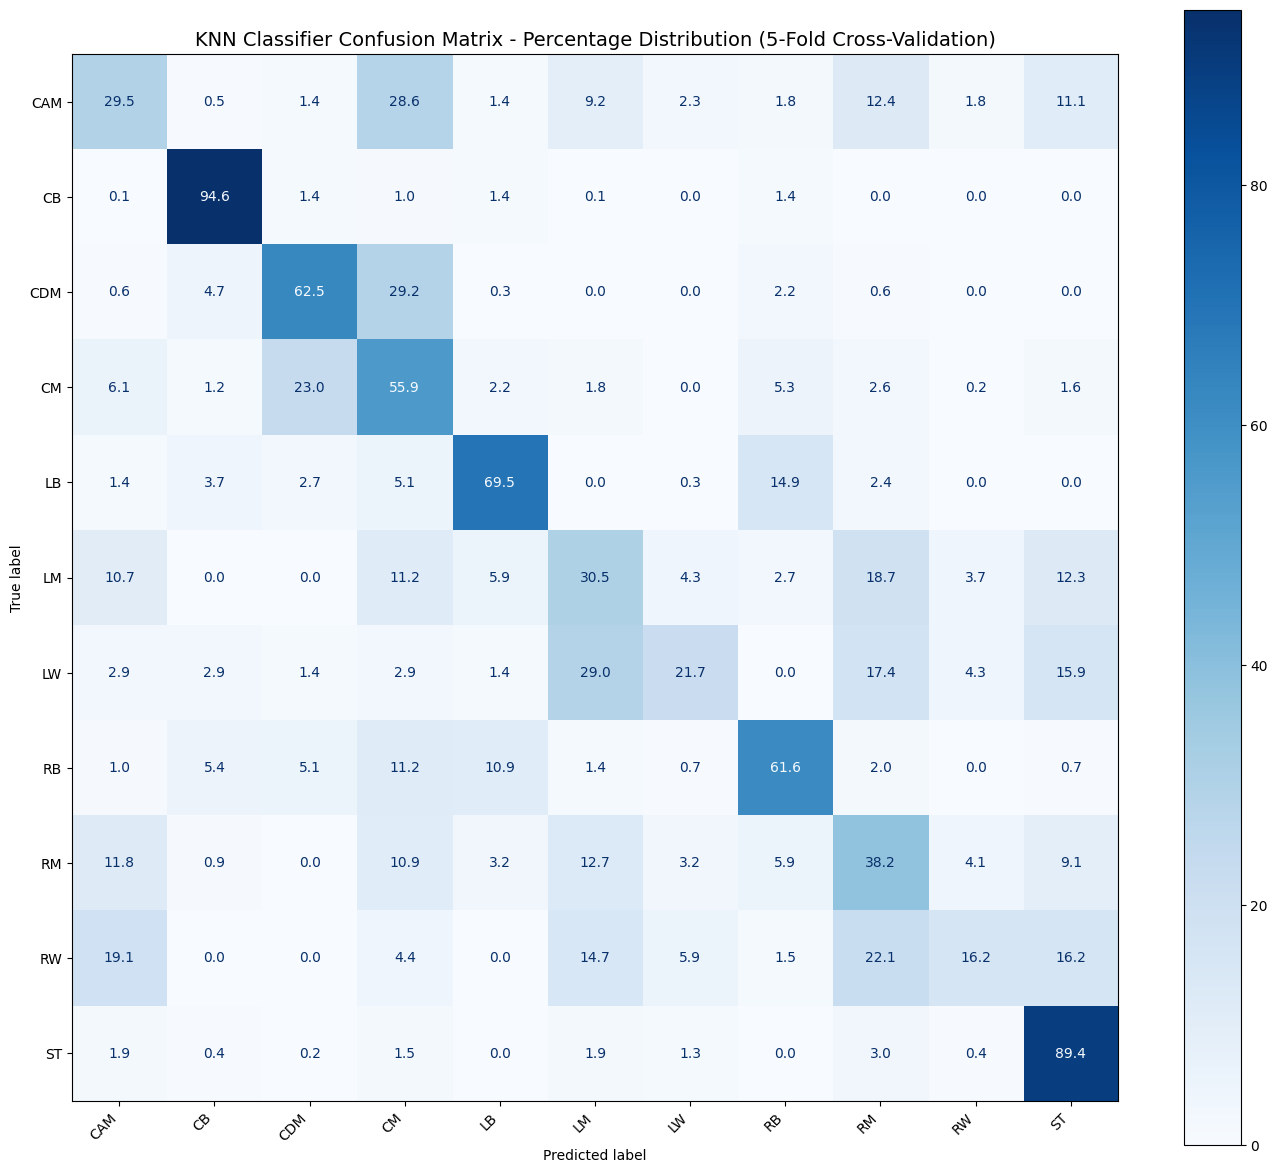

In [89]:
# Prepare data
df_knn = df_info_reset.copy()
valid_mask = df_knn["pos"].notna() & (df_knn["pos"] != "")
df_knn = df_knn.loc[valid_mask].copy()
X_knn = X_scaled[valid_mask.values]

# Train KNN with cross-validation
knn = KNeighborsClassifier(n_neighbors=5, weights="distance")
y_pred = cross_val_predict(knn, X_knn, df_knn["pos"], cv=5)

# Plot confusion matrix with percentages
cm = confusion_matrix(df_knn["pos"], y_pred)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

fig, ax = plt.subplots(figsize=(14, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_percent, display_labels=sorted(df_knn["pos"].unique()))
disp.plot(ax=ax, cmap='Blues', values_format='.1f')
ax.set_title("KNN Classifier Confusion Matrix - Percentage Distribution (5-Fold Cross-Validation)", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### KMeans clustering: Cluster players and look for minorities into clusters - MURA

#### KMeans algorithm

In [90]:
# Perform KMeans clustering with k=22
k = 30
kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled)

# Add cluster labels to the dataframe
df_clusters = df_info_reset.copy()
df_clusters['cluster'] = cluster_labels

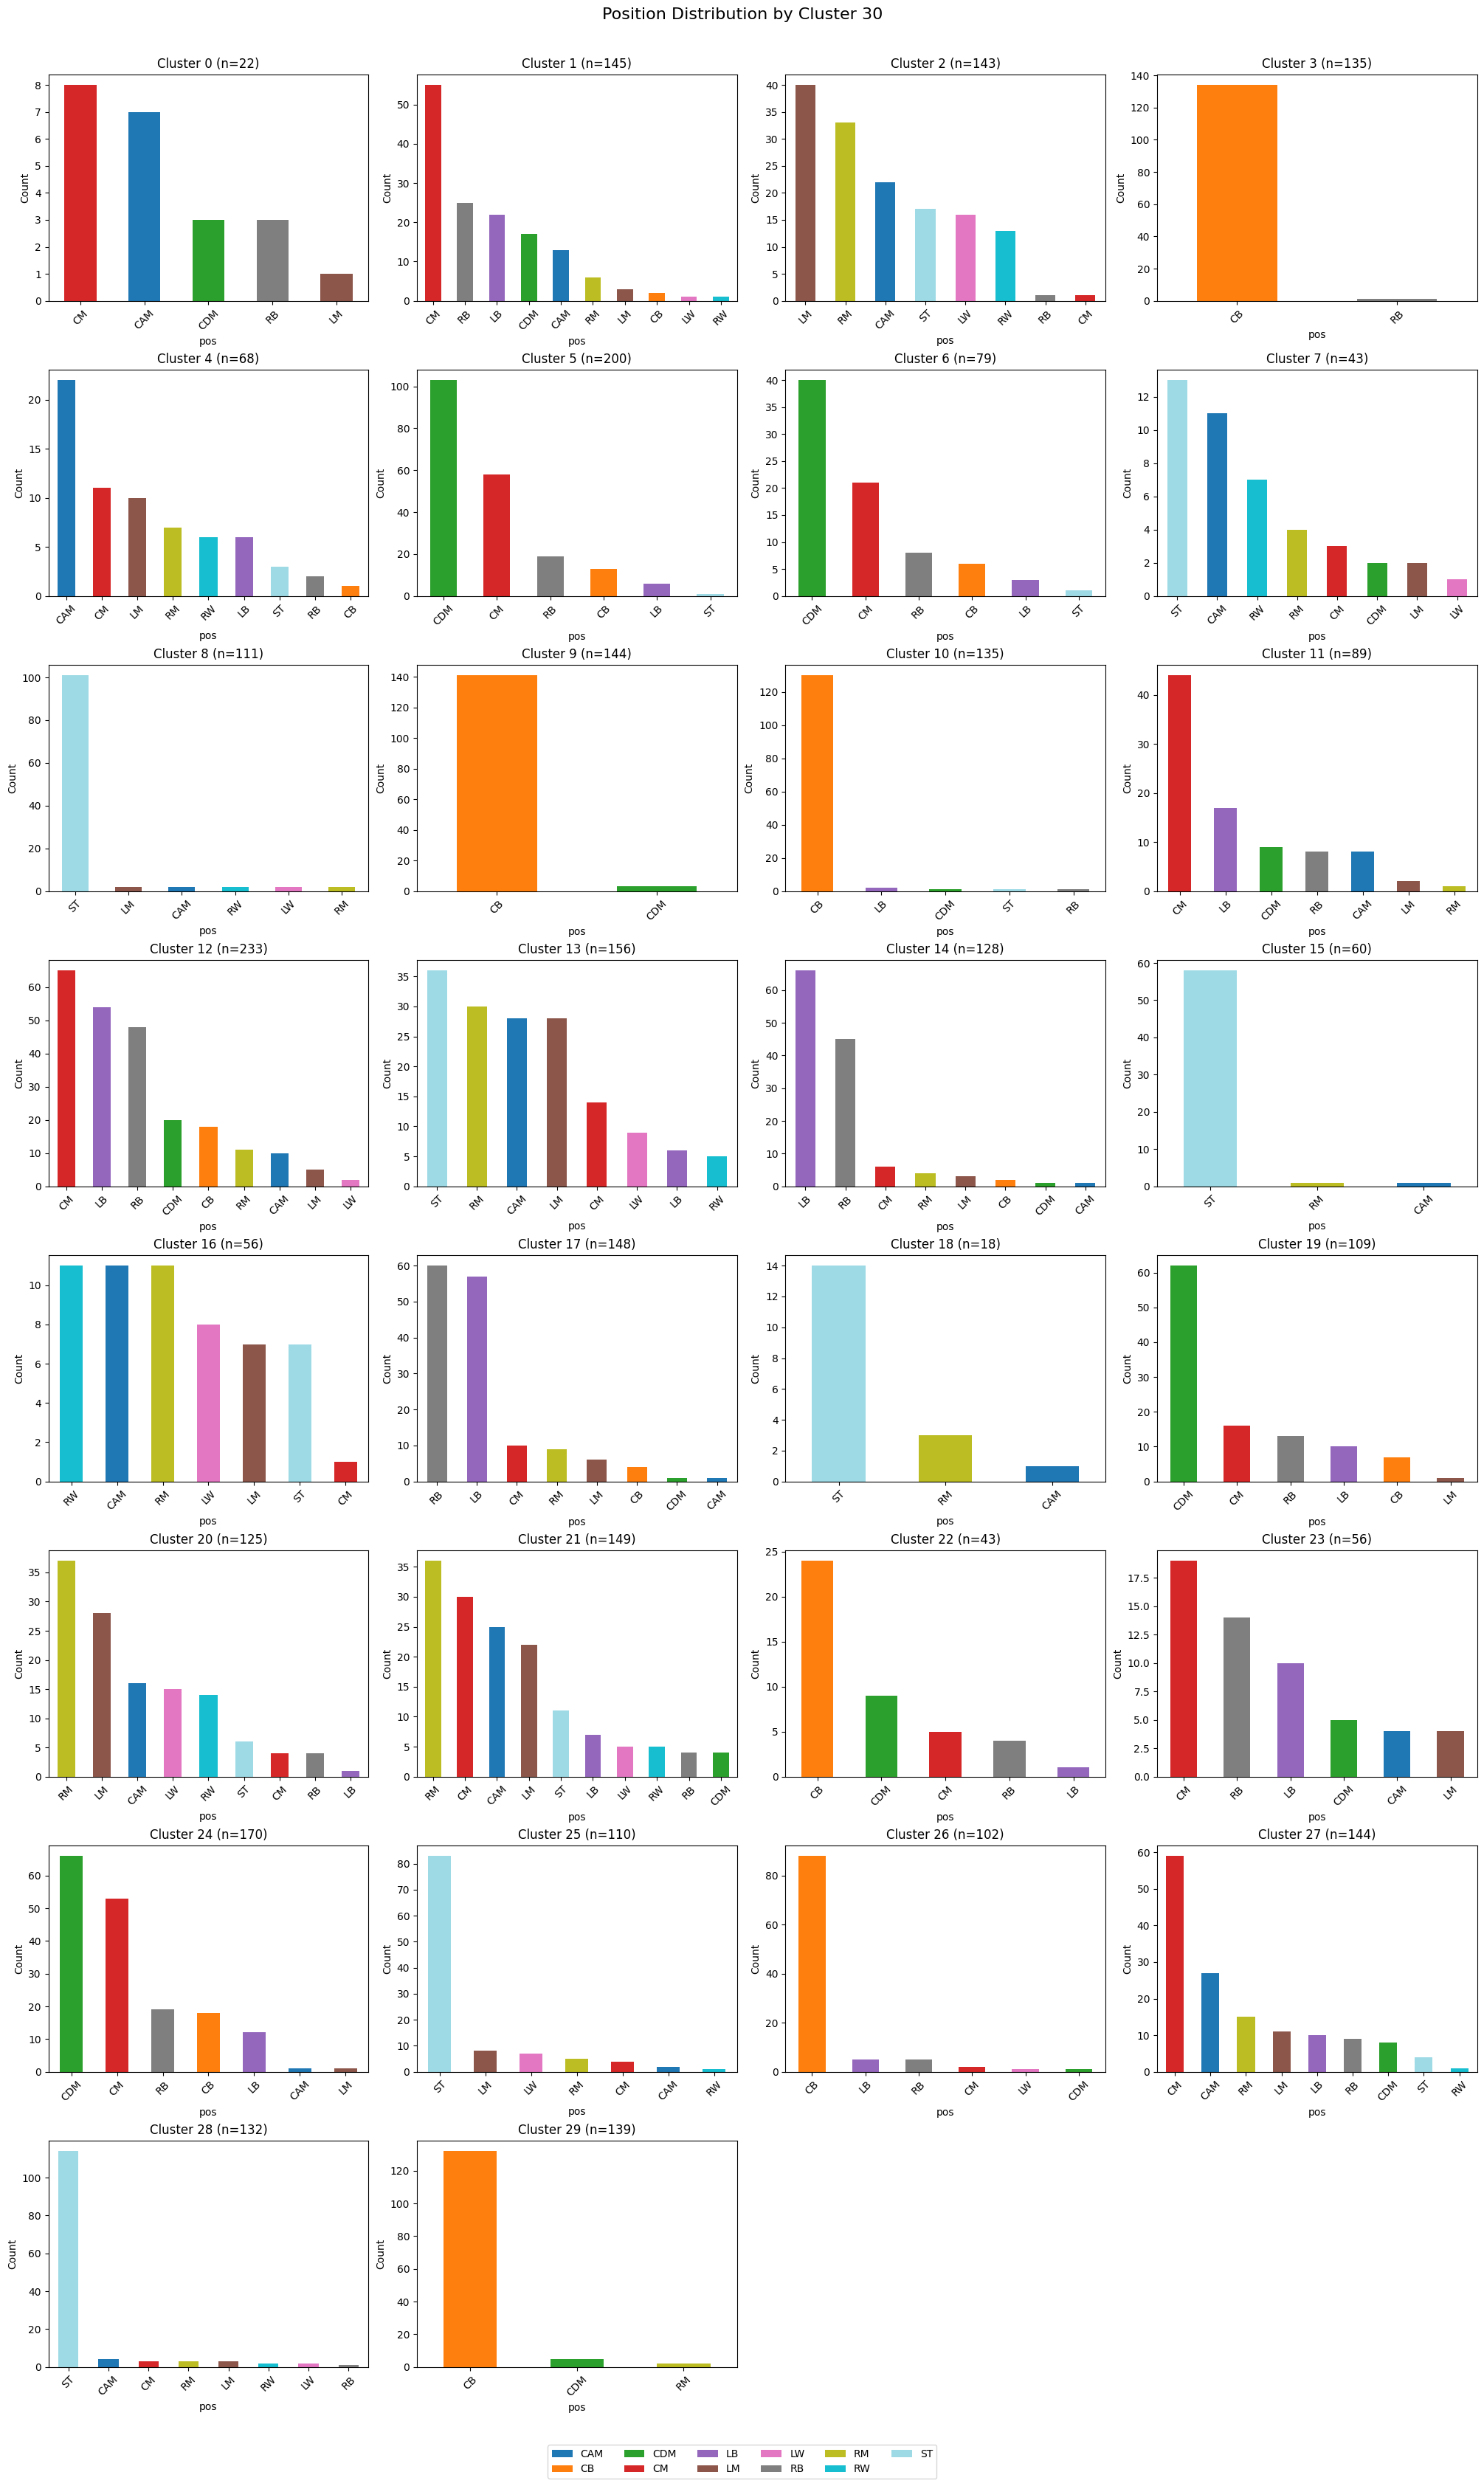

In [91]:
# ===========================================================================
#   Visualize the distribution of positions within each cluster for KMeans A
# ===========================================================================
cluster_col = "cluster"
pos_col = "pos"

# Create a color mapping for positions
unique_positions = sorted(df_clusters[pos_col].unique())
colors = plt.cm.tab20(np.linspace(0, 1, len(unique_positions)))
color_map = {pos: colors[i] for i, pos in enumerate(unique_positions)}

n_clusters = df_clusters[cluster_col].nunique()
n_cols = 4
n_rows = int(np.ceil(n_clusters / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows), constrained_layout=True)
axes = np.array(axes).ravel()

for cluster_id in sorted(df_clusters[cluster_col].unique()):
    ax = axes[cluster_id]
    cluster_data = df_clusters[df_clusters[cluster_col] == cluster_id]
    pos_counts = cluster_data[pos_col].value_counts()

    # Map colors to each position
    bar_colors = [color_map[pos] for pos in pos_counts.index]
    pos_counts.plot(kind="bar", ax=ax, color=bar_colors)
    ax.set_title(f"Cluster {cluster_id} (n={len(cluster_data)})")
    ax.set_xlabel("pos")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=45)

for j in range(n_clusters, len(axes)):
    fig.delaxes(axes[j])

# Create legend with position colors
legend_elements = [plt.Rectangle((0, 0), 1, 1, facecolor=color_map[pos], label=pos) for pos in unique_positions]
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.01), ncol=len(unique_positions)//2 + 1, fontsize=10)

plt.suptitle(f"Position Distribution by Cluster {k}", y=1.02, fontsize=16)
plt.show()

In [92]:
# 1. Compute the dominant role for each cluster
df_clusters['Dominant_Role_in_Cluster'] = df_clusters.groupby('cluster')['pos'].transform(
    lambda x: x.value_counts().idxmax()
)

# 2. Indentify minorities
hybrid_mask = df_clusters['pos'] != df_clusters['Dominant_Role_in_Cluster']
df_hybrid = df_clusters[hybrid_mask].copy()

# 3. cleaning and sorting for display
columns_to_show = ['player', 'team', 'league', 'pos', 'cluster', 'Dominant_Role_in_Cluster']
df_hybrid = df_hybrid[columns_to_show].sort_values(by=['cluster', 'pos'])

print(f"Found {len(df_hybrid)} players with an atypical tactical profile compared to their nominal role.\n")

Found 1531 players with an atypical tactical profile compared to their nominal role.



#### Cluster Analysis

In [93]:
# Create a comprehensive cluster profiling table
cluster_profile = []

for cluster_id in sorted(df_clusters['cluster'].unique()):
    cluster_data = df_clusters[df_clusters['cluster'] == cluster_id]
    
    # Most frequent position
    pos_counts = cluster_data['pos'].value_counts()
    most_freq_pos = pos_counts.index[0]
    most_freq_pos_count = pos_counts.iloc[0]
    most_freq_pos_pct = (most_freq_pos_count / len(cluster_data) * 100)
    most_freq_pos_str = f"{most_freq_pos}({most_freq_pos_count}, {most_freq_pos_pct:.1f}%)"
    
    # Other positions (as string) with percentages
    other_pos_list = []
    for pos, count in pos_counts.iloc[1:].items():
        pct = (count / len(cluster_data) * 100)
        other_pos_list.append(f"{pos}({count}, {pct:.1f}%)")
    other_pos = ', '.join(other_pos_list)
    
    # Top 5 most important features (using kmeans cluster centers)
    cluster_center = kmeans.cluster_centers_[cluster_id]
    top_5_features = np.argsort(np.abs(cluster_center))[-5:][::-1]
    top_5_features_names = [features[i] for i in top_5_features]
    
    cluster_profile.append({
        'cluster': cluster_id,
        'most freq pos': most_freq_pos_str,
        'player count': len(cluster_data),
        'other positions': other_pos if other_pos else 'None',
        'top 5 features': ' | '.join(top_5_features_names)
    })

df_cluster_profile = pd.DataFrame(cluster_profile)
display(df_cluster_profile)

,cluster,most freq pos,player count,other positions,top 5 features
0,0,"CM(8, 36.4%)",22,"CAM(7, 31.8%), CDM(3, 13.6%), RB(3, 13.6%), LM...",KP | Expected_xA | PPA | PrgP | Progression_PrgP
1,1,"CM(55, 37.9%)",145,"RB(25, 17.2%), LB(22, 15.2%), CDM(17, 11.7%), ...",Standard_G/SoT | Standard_G/Sh | Playing Time_...
2,2,"LM(40, 28.0%)",143,"RM(33, 23.1%), CAM(22, 15.4%), ST(17, 11.9%), ...",Per 90 Minutes_xAG | Per 90 Minutes_Ast | Carr...
3,3,"CB(134, 99.3%)",135,"RB(1, 0.7%)",Touches_Def Pen | Touches_Def 3rd | Clr | Medi...
4,4,"CAM(22, 32.4%)",68,"CM(11, 16.2%), LM(10, 14.7%), RM(7, 10.3%), RW...",xAG | Expected_xAG | Expected_xA | KP | Ast
5,5,"CDM(103, 51.5%)",200,"CM(58, 29.0%), RB(19, 9.5%), CB(13, 6.5%), LB(...",Receiving_PrgR | Progression_PrgR | Touches_At...
6,6,"CDM(40, 50.6%)",79,"CM(21, 26.6%), RB(8, 10.1%), CB(6, 7.6%), LB(3...",Tackles_Mid 3rd | Touches_Mid 3rd | 1/3 | Chal...
7,7,"ST(13, 30.2%)",43,"CAM(11, 25.6%), RW(7, 16.3%), RM(4, 9.3%), CM(...",Standard_PK | Performance_PK | Performance_PKa...
8,8,"ST(101, 91.0%)",111,"LM(2, 1.8%), CAM(2, 1.8%), RW(2, 1.8%), LW(2, ...",Expected_npxG | Expected_xG | Standard_SoT | P...
9,9,"CB(141, 97.9%)",144,"CDM(3, 2.1%)",Clr | Blocks_Sh | Touches_Def Pen | Touches_De...


In [94]:
def valuta_significativita_cluster(df_summary):
    print("🏆 CLASSIFICA SIGNIFICATIVITÀ DEI CLUSTER TATTICI 🏆\n")
    
    cluster_scores = []
    
    for _, row in df_summary.iterrows():
        cluster_id = row['cluster']
        features = str(row['top 5 features']).lower()
        size = row['player count']
        
        score = 100 # Punteggio base
        motivi = []
        
        # 1. Penalità per i "Calderoni del minutaggio"
        if any(x in features for x in ['playing time', '90s', 'min', 'starts']):
            score -= 50
            motivi.append("❌ Penalità: Cluster basato sui Minuti Giocati (poco tattico)")
            
        # 2. Penalità per cluster troppo legati ai Rigori (PK)
        if 'pk' in features:
            score -= 30
            motivi.append("⚠️ Attenzione: Cluster dominato dai Rigoristi")
            
        # 3. Bonus per Cardinalità ottimale (Elite o Specifici: 40-150)
        if 40 <= size <= 150:
            score += 20
            motivi.append("✅ Bonus: Dimensione ideale per un archetipo tattico (40-150)")
        elif size > 250:
            score -= 20
            motivi.append("📉 Penalità: Cluster troppo grande (generalista)")
            
        # 4. Analisi Ibridazione
        dominant_str = str(row['most freq pos'])
        if '%' in dominant_str:
            perc = float(dominant_str.split(',')[1].replace('%', '').replace(')', '').strip())
            if perc > 90:
                motivi.append("🧱 Cluster purissimo (quasi solo 1 ruolo)")
            elif 30 <= perc <= 70:
                score += 15
                motivi.append("🧬 Bonus: Ottimo mix di ruoli ibridi")
                
        cluster_scores.append({
            'cluster': cluster_id,
            'score': score,
            'ruolo': dominant_str.split('(')[0],
            'features': row['top 5 features'],
            'motivazioni': " | ".join(motivi)
        })
        
    # Crea e mostra il dataframe ordinato per punteggio
    df_scores = pd.DataFrame(cluster_scores).sort_values(by='score', ascending=False)
    
    display(df_scores)
    
# Esegui la funzione passandogli il dataframe riassuntivo
valuta_significativita_cluster(df_cluster_profile)

🏆 CLASSIFICA SIGNIFICATIVITÀ DEI CLUSTER TATTICI 🏆



,cluster,score,ruolo,features,motivazioni
4,4,135,CAM,xAG | Expected_xAG | Expected_xA | KP | Ast,✅ Bonus: Dimensione ideale per un archetipo ta...
6,6,135,CDM,Tackles_Mid 3rd | Touches_Mid 3rd | 1/3 | Chal...,✅ Bonus: Dimensione ideale per un archetipo ta...
11,11,135,CM,Short_Cmp | Short_Att | PrgP | Progression_Prg...,✅ Bonus: Dimensione ideale per un archetipo ta...
23,23,135,CM,Challenges_Att | Challenges_Lost | Tackles_Tkl...,✅ Bonus: Dimensione ideale per un archetipo ta...
19,19,135,CDM,Tackles_Tkl | Tkl+Int | Tackles_Mid 3rd | Tack...,✅ Bonus: Dimensione ideale per un archetipo ta...
14,14,135,LB,CrsPA | Tackles_Def 3rd | Challenges_Tkl | Tac...,✅ Bonus: Dimensione ideale per un archetipo ta...
22,22,135,CB,1/3 | Receiving_Rec | Total_Cmp | Touches_Mid ...,✅ Bonus: Dimensione ideale per un archetipo ta...
27,27,135,CM,Blocks_Pass | Challenges_Lost | Tackles_Mid 3r...,✅ Bonus: Dimensione ideale per un archetipo ta...
21,21,120,RM,Total_Cmp | Total_TotDist | Medium_Att | Total...,✅ Bonus: Dimensione ideale per un archetipo ta...
20,20,120,RM,Carries_CPA | Carries_PrgC | Progression_PrgC ...,✅ Bonus: Dimensione ideale per un archetipo ta...


In [103]:
df_clusters[df_clusters['cluster'] == 4]['pos'].value_counts()

pos
CAM    22
CM     11
LM     10
RM      7
RW      6
LB      6
ST      3
RB      2
CB      1
Name: count, dtype: int64

#### SVM

In [95]:
from sklearn.svm import OneClassSVM

# Detect anomalies within each role using One-Class SVM
svm_anomalies = []

for role in sorted(df_info_reset["pos"].dropna().unique()):
    role_mask = df_info_reset["pos"] == role
    X_role = X_scaled[role_mask.values]

    # Skip roles with too few samples
    if X_role.shape[0] < 10:
        continue

    ocsvm = OneClassSVM(kernel="rbf", nu=0.05, gamma="scale")
    y_role = ocsvm.fit_predict(X_role)
    scores = ocsvm.decision_function(X_role)

    df_role = df_info_reset.loc[role_mask, ["league", "season", "team", "player", "nation", "age", "pos"]].copy()
    df_role["svm_label"] = y_role
    df_role["svm_score"] = scores
    df_role["is_anomaly"] = df_role["svm_label"] == -1

    svm_anomalies.append(df_role)

df_svm_anomalies = pd.concat(svm_anomalies, ignore_index=True)

# Most anomalous players first within each role
df_svm_anomalies = df_svm_anomalies.sort_values(["pos", "svm_score", "player"]).reset_index(drop=True)

# Display anomalies only
df_svm_outliers = df_svm_anomalies[df_svm_anomalies["is_anomaly"]].sort_values(["pos", "svm_score"])
display(df_svm_outliers)

print("Anomalies per role:")
display(df_svm_outliers.groupby("pos").size().reset_index(name="anomaly_count"))

,league,season,team,player,nation,age,pos,svm_label,svm_score,is_anomaly
0,GER-Bundesliga,2024 - 2025,Leverkusen,Florian Wirtz,GER,21,CAM,-1,-0.000446,True
1,ITA-Serie A,2023 - 2024,Frosinone,Matìas Soulé,ARG,20,CAM,-1,-0.000424,True
2,ENG-Premier League,2022 - 2023,Manchester Utd,Bruno Fernandes,POR,27,CAM,-1,-0.000341,True
3,ITA-Serie A,2023 - 2024,Roma,Paulo Dybala,ARG,29,CAM,-1,-0.000324,True
4,GER-Bundesliga,2023 - 2024,Heidenheim,Eren Dinkçi,GER,21,CAM,-1,-0.000313,True
...,...,...,...,...,...,...,...,...,...,...
2943,ITA-Serie A,2023 - 2024,Genoa,Albert Guðmundsson,ISL,26,ST,-1,-0.000088,True
2944,ESP-La Liga,2024 - 2025,Atlético Madrid,Alexander Sørloth,NOR,28,ST,-1,-0.000076,True
2945,ESP-La Liga,2023 - 2024,Villarreal,Alexander Sørloth,NOR,27,ST,-1,-0.000051,True
2946,GER-Bundesliga,2023 - 2024,Werder Bremen,Marvin Ducksch,GER,29,ST,-1,-0.000001,True


Anomalies per role:


,pos,anomaly_count
0,CAM,20
1,CB,38
2,CDM,27
3,CM,34
4,LB,26
5,LM,21
6,LW,10
7,RB,26
8,RM,20
9,RW,11


In [96]:
# Add top 5 features that make each outlier look anomalous
X_reset = X.reset_index(drop=True)
info_reset = df_info_reset.reset_index(drop=True)

anomaly_features = []
anomaly_scores = []

for _, row in df_svm_outliers.iterrows():
    match_mask = (
        (info_reset["player"] == row["player"]) &
        (info_reset["season"] == row["season"]) &
        (info_reset["team"] == row["team"]) &
        (info_reset["pos"] == row["pos"])
    )
    match_idx = info_reset.index[match_mask]

    if len(match_idx) == 0:
        anomaly_features.append("")
        anomaly_scores.append("")
        continue

    idx = match_idx[0]
    role_mask = info_reset["pos"] == row["pos"]

    role_X = X_reset.loc[role_mask.values, features]
    role_mean = role_X.mean()
    role_std = role_X.std(ddof=0).replace(0, np.nan)

    player_values = X_reset.loc[idx, features]
    z_scores = ((player_values - role_mean) / role_std).abs().dropna().sort_values(ascending=False)

    top5 = z_scores.head(5)
    anomaly_features.append(" | ".join(top5.index.tolist()))
    anomaly_scores.append(" | ".join(top5.round(2).astype(str).tolist()))

df_svm_outliers = df_svm_outliers.copy()
df_svm_outliers["top_5_anomaly_features"] = anomaly_features
df_svm_outliers["top_5_anomaly_scores"] = anomaly_scores

display(
    df_svm_outliers[
        ["league", "season", "team", "player", "pos", "svm_score", "top_5_anomaly_features", "top_5_anomaly_scores"]
    ].head(20)
)

,league,season,team,player,pos,svm_score,top_5_anomaly_features,top_5_anomaly_scores
0,GER-Bundesliga,2024 - 2025,Leverkusen,Florian Wirtz,CAM,-0.000446,Progression_PrgR | Receiving_PrgR | Touches_At...,3.39 | 3.39 | 3.39 | 2.97 | 2.95
1,ITA-Serie A,2023 - 2024,Frosinone,Matìas Soulé,CAM,-0.000424,Take-Ons_Tkld | Take-Ons_Att | Take-Ons_Succ |...,4.27 | 4.25 | 3.89 | 3.48 | 3.11
2,ENG-Premier League,2022 - 2023,Manchester Utd,Bruno Fernandes,CAM,-0.000341,Expected_A-xAG | xAG | Expected_xAG | KP | Exp...,5.08 | 5.03 | 5.03 | 3.8 | 3.74
3,ITA-Serie A,2023 - 2024,Roma,Paulo Dybala,CAM,-0.000324,Performance_PK | Standard_PK | Performance_PKa...,4.16 | 4.16 | 3.71 | 3.71 | 2.86
4,GER-Bundesliga,2023 - 2024,Heidenheim,Eren Dinkçi,CAM,-0.000313,Expected_np:G-xG | Expected_G-xG | Short_Cmp% ...,3.03 | 2.94 | 2.89 | 2.58 | 2.25
5,ENG-Premier League,2023 - 2024,Chelsea,Cole Palmer,CAM,-0.000295,Performance_PK | Standard_PK | Performance_PKa...,5.49 | 5.49 | 4.92 | 4.92 | 4.41
6,ENG-Premier League,2022 - 2023,Brentford,Mikkel Damsgaard,CAM,-0.000274,Expected_npxG/Sh | Per 90 Minutes_G+A-PK | Per...,3.44 | 1.96 | 1.91 | 1.91 | 1.75
7,GER-Bundesliga,2023 - 2024,Bochum,Kevin Stöger,CAM,-0.000245,CrsPA | KP | Total_PrgDist | Long_Att | Progre...,4.25 | 4.16 | 3.81 | 3.36 | 3.17
8,GER-Bundesliga,2024 - 2025,Freiburg,Merlin Röhl,CAM,-0.000218,Long_Cmp% | Challenges_Tkl% | Height | Take-On...,3.82 | 3.54 | 2.28 | 2.05 | 1.91
9,GER-Bundesliga,2022 - 2023,Schalke 04,Rodrigo Zalazar,CAM,-0.000118,Total_Cmp% | Short_Cmp% | Per 90 Minutes_Ast |...,2.72 | 2.14 | 2.07 | 1.99 | 1.61


### Autoencoder Reconstruction Error - BOSCA

## End

In [97]:
end_time = time.time()

In [98]:

elapsed_time = end_time - start_time
elapsed_minutes = round(elapsed_time / 60)
remaining_seconds = round(elapsed_time % 60)
print(f"\nTotal execution time: {elapsed_minutes:.0f}.{remaining_seconds:.0f} min")


Total execution time: 0.20 min
